In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [12]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00560/SeoulBikeData.csv"
data = pd.read_csv(url,sep=',',encoding='unicode_escape')
data


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [9]:
fdata = data.loc[data["Rainfall(mm)"] ==0]
# fdata = data

<Axes: xlabel='Date', ylabel='Rented Bike Count'>

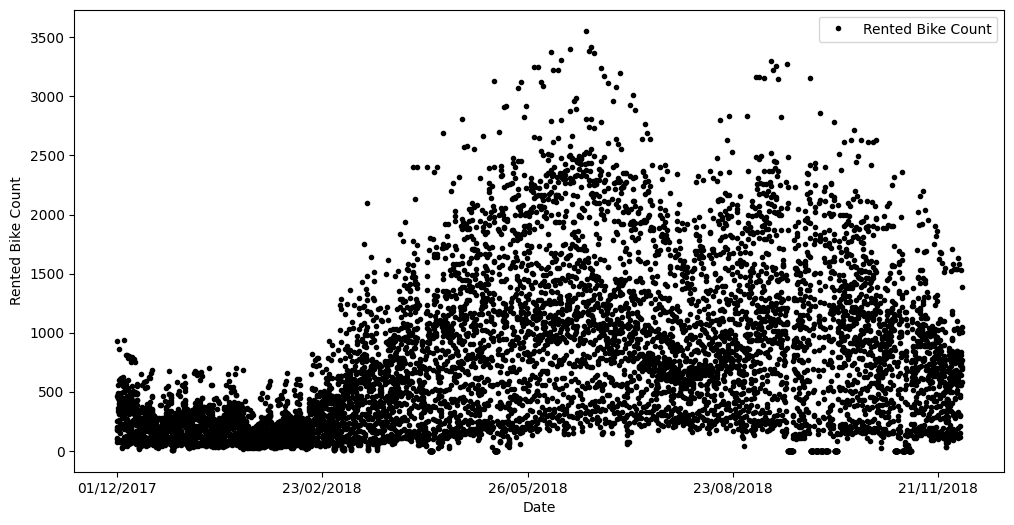

In [15]:
fdata.plot(x='Date',y='Rented Bike Count',color='k',marker='.',linestyle='none',
          figsize=(12,6),ylabel='Rented Bike Count')


In [14]:
fdata.replace(['Spring','Summer', 'Autumn','Winter'],[1,1,0,0], inplace=True)

desmat_df = fdata[["Rainfall(mm)", "Visibility (10m)"]]
obsdata_df = fdata["Rented Bike Count"]
desmat_df = sm.add_constant(desmat_df)

model = sm.OLS(obsdata_df,desmat_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Rented Bike Count   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     195.5
Date:                Sun, 14 Sep 2025   Prob (F-statistic):           6.31e-44
Time:                        02:14:31   Log-Likelihood:                -64861.
No. Observations:                8232   AIC:                         1.297e+05
Df Residuals:                    8230   BIC:                         1.297e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              491.1471     19.095  

/home/rizvian/Documents/github/python/.venv/lib64/python3.13/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [11]:
a = np.array([[1,-1],[1,1]])/np.sqrt(2)
print (a.T@a)

[[1. 0.]
 [0. 1.]]
